# EDA — Transformers: BPE Tokenization for EN→ES Translation

Exploring how BPE (Byte Pair Encoding) subword tokenization changes the Tatoeba EN→ES dataset compared to the word-level tokenization used in Attention (#15). Same raw data, different tokenization strategy — this drives the preprocessing decisions for the Transformer pipeline.

**Key questions:**
1. How does BPE handle words that were `<UNK>` in #15?
2. How much longer do BPE sequences get vs word-level?
3. What shared vocabulary size balances coverage and efficiency?

In [1]:
# Step 1: Setup + Raw Data Overview
"""
Load the same Tatoeba EN→ES raw data used in Attention (#15).
Goal: understand the raw data characteristics that will inform
our BPE tokenization decisions in preprocessing.

Attention #15 used word-level tokenization with these results:
  - EN vocab: 10,004 (10K + 4 special tokens)
  - ES vocab: 10,004
  - EN UNK rate: 2.6%    (words lost to <UNK>)
  - ES UNK rate: 7.3%    (Spanish has more morphological variety)
  - MAX_LENGTH: 20 tokens
  - Filtered pairs: ~143K → 114K train / 14K val / 14K test

BPE (Byte Pair Encoding) will replace word-level tokenization:
  - Splits rare words into common subword units
  - Eliminates <UNK> entirely (every word decomposes into known pieces)
  - Uses a SHARED vocab across both languages (standard for Transformers)
  - Trade-off: sequences get longer (rare words = multiple tokens)
"""

import numpy as np
import os
from collections import Counter

RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("[1/4] SETUP + RAW DATA OVERVIEW")
print("=" * 60)

# Load raw data (same file as Attention #15)
raw_path = '../data/raw/attention/spa.txt'
pairs = []
with open(raw_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            pairs.append((parts[0].strip(), parts[1].strip()))

print(f"\n  Raw pairs loaded: {len(pairs):,}")
print(f"  Source: {raw_path}")

# Random samples
print(f"\n  Sample pairs:")
idx = np.random.choice(len(pairs), 5, replace=False)
for i in idx:
    en, es = pairs[i]
    print(f"    [{i:>6}] EN: {en}")
    print(f"           ES: {es}")

# Word-level length distributions
# Simple whitespace split to understand raw lengths before BPE
en_lengths = [len(en.split()) for en, es in pairs]
es_lengths = [len(es.split()) for en, es in pairs]

print(f"\n  {'':=<60}")
print(f"  Raw Word-Level Length Statistics")
print(f"  {'':=<60}")
print(f"  {'Metric':<12} {'English':>10} {'Spanish':>10}")
print(f"  {'-'*32}")
print(f"  {'Mean':<12} {np.mean(en_lengths):>10.1f} {np.mean(es_lengths):>10.1f}")
print(f"  {'Median':<12} {np.median(en_lengths):>10.1f} {np.median(es_lengths):>10.1f}")
print(f"  {'P90':<12} {np.percentile(en_lengths, 90):>10.0f} {np.percentile(es_lengths, 90):>10.0f}")
print(f"  {'P95':<12} {np.percentile(en_lengths, 95):>10.0f} {np.percentile(es_lengths, 95):>10.0f}")
print(f"  {'P99':<12} {np.percentile(en_lengths, 99):>10.0f} {np.percentile(es_lengths, 99):>10.0f}")
print(f"  {'Max':<12} {max(en_lengths):>10} {max(es_lengths):>10}")

# Reference: Attention #15 preprocessing choices
print(f"\n  {'':=<60}")
print(f"  Attention #15 Reference (word-level)")
print(f"  {'':=<60}")
print(f"  Vocab:       10,004 per language (separate EN + ES)")
print(f"  UNK rate:    EN 2.6%, ES 7.3%")
print(f"  MAX_LENGTH:  20 tokens")
print(f"  Pairs used:  143,098 (after length filtering)")
print(f"  Split:       114K train / 14K val / 14K test")

[1/4] SETUP + RAW DATA OVERVIEW

  Raw pairs loaded: 144,215
  Source: ../data/raw/attention/spa.txt

  Sample pairs:
    [142986] EN: The good thing about this electronic dictionary is that it's easy to carry.
           ES: Lo bueno de este diccionario electrónico es que es fácil de portar.
    [135715] EN: On the American flag, there's a star for every state.
           ES: En la bandera de los Estados Unidos hay una estrella por cada estado.
    [135727] EN: Please give me two hot dogs with mustard and ketchup.
           ES: Por favor dame dos hot dogs con mostaza y salsa de tomate.
    [ 79839] EN: Can I use my medical insurance?
           ES: ¿Puedo usar mi seguro médico?
    [139457] EN: This looks longer than that, but it is an optical illusion.
           ES: Esto parece más largo que eso, pero es una ilusión óptica.

  Raw Word-Level Length Statistics
  Metric          English    Spanish
  --------------------------------
  Mean                6.2        6.0
  Median       

[2/4] BPE TOKENIZATION EXPLORATION

  Temp BPE model: 8,000 shared vocab

  BPE vs Word-Level Examples

    EN: "The good thing about this electronic dictionary is that it's easy to carry."
      Word-level: 13 tokens → ['the', 'good', 'thing', 'about', 'this', 'electronic', 'dictionary', 'is', 'that', "it's", 'easy', 'to', 'carry.']
      BPE:        18 tokens → ['▁the', '▁good', '▁thing', '▁about', '▁this', '▁elect', 'ron', 'ic', '▁dictionary', '▁is', '▁that', '▁it', "'", 's', '▁easy', '▁to', '▁carry', '.']
    ES: "Lo bueno de este diccionario electrónico es que es fácil de portar."
      Word-level: 12 tokens → ['lo', 'bueno', 'de', 'este', 'diccionario', 'electrónico', 'es', 'que', 'es', 'fácil', 'de', 'portar.']
      BPE:        16 tokens → ['▁lo', '▁bueno', '▁de', '▁este', '▁diccionario', '▁elect', 'rón', 'ico', '▁es', '▁que', '▁es', '▁fácil', '▁de', '▁por', 'tar', '.']

    EN: "On the American flag, there's a star for every state."
      Word-level: 10 tokens → ['on', 'the', 

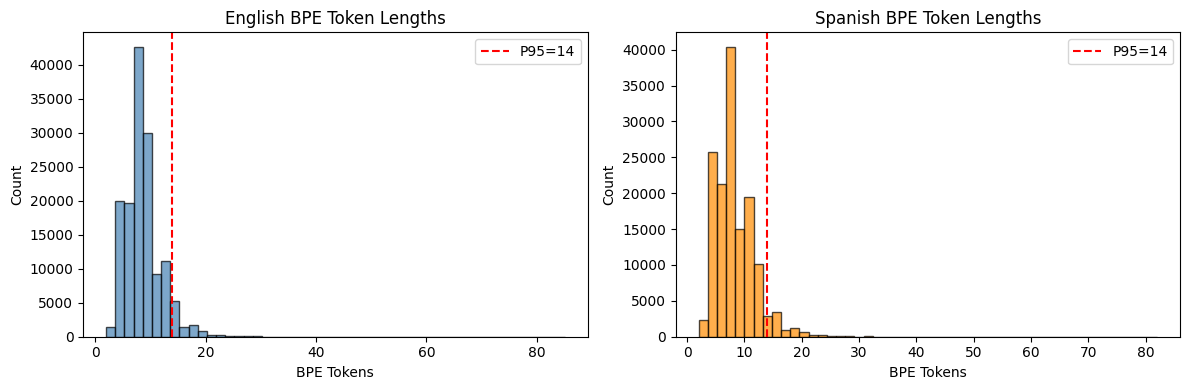


  Temp BPE model cleaned up


In [2]:
# Step 2: BPE Tokenization Exploration
"""
Train a temporary BPE model to explore how subword tokenization
changes sequence characteristics. This is for analysis only —
the real BPE model is trained in the preprocessing script.

BPE (Byte Pair Encoding) works by:
  1. Start with individual characters as the vocabulary
  2. Find the most frequent pair of adjacent tokens
  3. Merge that pair into a new token
  4. Repeat until vocab_size is reached

Result: common words stay whole ("the", "is"), rare words split
into subword pieces ("firefighter" → "fire" + "fighter").
"""

import sentencepiece as spm
import tempfile
import matplotlib.pyplot as plt

print("=" * 60)
print("[2/4] BPE TOKENIZATION EXPLORATION")
print("=" * 60)

# Train temporary BPE model for exploration
BPE_VOCAB_SIZE = 8000

with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as tmp:
    for en, es in pairs:
        tmp.write(en.lower() + '\n')
        tmp.write(es.lower() + '\n')
    tmp_path = tmp.name

spm.SentencePieceTrainer.train(
    input=tmp_path,
    model_prefix='bpe_explore',
    vocab_size=BPE_VOCAB_SIZE,
    model_type='bpe',
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    character_coverage=1.0,
    shuffle_input_sentence=True,
)
os.remove(tmp_path)

sp = spm.SentencePieceProcessor()
sp.load('bpe_explore.model')
print(f"\n  Temp BPE model: {BPE_VOCAB_SIZE:,} shared vocab")

# BPE vs Word-Level: side-by-side examples
print(f"\n  {'':=<60}")
print(f"  BPE vs Word-Level Examples")
print(f"  {'':=<60}")

demo_indices = [142986, 135715, 79839, 139457, 0]  # reuse some from Cell 1
for i in demo_indices:
    en, es = pairs[i]
    en_words = en.lower().split()
    en_bpe = sp.encode(en.lower(), out_type=str)
    es_words = es.lower().split()
    es_bpe = sp.encode(es.lower(), out_type=str)
    print(f"\n    EN: \"{en}\"")
    print(f"      Word-level: {len(en_words)} tokens → {en_words}")
    print(f"      BPE:        {len(en_bpe)} tokens → {en_bpe}")
    print(f"    ES: \"{es}\"")
    print(f"      Word-level: {len(es_words)} tokens → {es_words}")
    print(f"      BPE:        {len(es_bpe)} tokens → {es_bpe}")

# Sequence length distributions: BPE vs word-level
en_bpe_lengths = [len(sp.encode(en.lower())) for en, es in pairs]
es_bpe_lengths = [len(sp.encode(es.lower())) for en, es in pairs]

print(f"\n  {'':=<60}")
print(f"  Length Comparison: Word-Level vs BPE")
print(f"  {'':=<60}")
print(f"  {'Metric':<12} {'EN Word':>10} {'EN BPE':>10} {'ES Word':>10} {'ES BPE':>10}")
print(f"  {'-'*52}")
print(f"  {'Mean':<12} {np.mean(en_lengths):>10.1f} {np.mean(en_bpe_lengths):>10.1f} {np.mean(es_lengths):>10.1f} {np.mean(es_bpe_lengths):>10.1f}")
print(f"  {'Median':<12} {np.median(en_lengths):>10.1f} {np.median(en_bpe_lengths):>10.1f} {np.median(es_lengths):>10.1f} {np.median(es_bpe_lengths):>10.1f}")
print(f"  {'P90':<12} {np.percentile(en_lengths, 90):>10.0f} {np.percentile(en_bpe_lengths, 90):>10.0f} {np.percentile(es_lengths, 90):>10.0f} {np.percentile(es_bpe_lengths, 90):>10.0f}")
print(f"  {'P95':<12} {np.percentile(en_lengths, 95):>10.0f} {np.percentile(en_bpe_lengths, 95):>10.0f} {np.percentile(es_lengths, 95):>10.0f} {np.percentile(es_bpe_lengths, 95):>10.0f}")
print(f"  {'P99':<12} {np.percentile(en_lengths, 99):>10.0f} {np.percentile(en_bpe_lengths, 99):>10.0f} {np.percentile(es_lengths, 99):>10.0f} {np.percentile(es_bpe_lengths, 99):>10.0f}")
print(f"  {'Max':<12} {max(en_lengths):>10} {max(en_bpe_lengths):>10} {max(es_lengths):>10} {max(es_bpe_lengths):>10}")

# Expansion ratio
en_ratio = np.mean(en_bpe_lengths) / np.mean(en_lengths)
es_ratio = np.mean(es_bpe_lengths) / np.mean(es_lengths)
print(f"\n  BPE expansion ratio (BPE/word): EN {en_ratio:.2f}x, ES {es_ratio:.2f}x")

# Histogram: BPE lengths
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(en_bpe_lengths, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.percentile(en_bpe_lengths, 95), color='red', linestyle='--', label=f'P95={np.percentile(en_bpe_lengths, 95):.0f}')
axes[0].set_title('English BPE Token Lengths')
axes[0].set_xlabel('BPE Tokens')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(es_bpe_lengths, bins=50, alpha=0.7, color='darkorange', edgecolor='black')
axes[1].axvline(np.percentile(es_bpe_lengths, 95), color='red', linestyle='--', label=f'P95={np.percentile(es_bpe_lengths, 95):.0f}')
axes[1].set_title('Spanish BPE Token Lengths')
axes[1].set_xlabel('BPE Tokens')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Clean up temp model files
os.remove('bpe_explore.model')
os.remove('bpe_explore.vocab')
print(f"\n  Temp BPE model cleaned up")


In [4]:
# Step 3: Shared Vocabulary Analysis
"""
Transformers typically use a SHARED vocabulary across source and target
languages, unlike Attention #15 which had separate EN and ES vocabs.

Why shared? Related languages (EN/ES) share cognates, numbers, and
punctuation. A shared BPE vocab naturally captures these overlaps and
reduces total vocab size. This cell explores what the shared vocab
looks like and whether 8K is the right size.
"""

print("=" * 60)
print("[3/4] SHARED VOCABULARY ANALYSIS")
print("=" * 60)

# Write combined corpus to temp file
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as tmp:
    for en, es in pairs:
        tmp.write(en.lower() + '\n')
        tmp.write(es.lower() + '\n')
    tmp_path = tmp.name

# Random sample for representative stats (pairs[:5000] is biased — file is sorted by length)
sample_idx = np.random.choice(len(pairs), 5000, replace=False)
sample_pairs = [pairs[i] for i in sample_idx]

# Train at multiple vocab sizes to compare trade-off
vocab_sizes = [4000, 8000, 16000]
results = {}

for vs in vocab_sizes:
    spm.SentencePieceTrainer.train(
        input=tmp_path,
        model_prefix=f'bpe_explore_{vs}',
        vocab_size=vs,
        model_type='bpe',
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,
        character_coverage=1.0,
        shuffle_input_sentence=True,
    )
    sp_tmp = spm.SentencePieceProcessor()
    sp_tmp.load(f'bpe_explore_{vs}.model')

    # Avg tokens per sentence at this vocab size (sample 5K for speed)
    en_lens = [len(sp_tmp.encode(en.lower())) for en, es in sample_pairs]
    es_lens = [len(sp_tmp.encode(es.lower())) for en, es in sample_pairs]
    results[vs] = {
        'en_mean': np.mean(en_lens),
        'es_mean': np.mean(es_lens),
        'sp': sp_tmp,  # keep 8K model for vocab inspection
    }

# Clean up temp corpus
os.remove(tmp_path)

# Print comparison table
print(f"\n  Vocab Size vs Avg Sequence Length (sample of 5K pairs)")
print(f"  {'Vocab':>8} {'EN Mean':>10} {'ES Mean':>10} {'EN Ratio':>10} {'ES Ratio':>10}")
print(f"  {'-'*48}")

en_word_5k = np.mean([len(en.split()) for en, es in sample_pairs])
es_word_5k = np.mean([len(es.split()) for en, es in sample_pairs])

for vs in vocab_sizes:
    en_r = results[vs]['en_mean'] / en_word_5k
    es_r = results[vs]['es_mean'] / es_word_5k
    print(f"  {vs:>8,} {results[vs]['en_mean']:>10.1f} {results[vs]['es_mean']:>10.1f} {en_r:>9.2f}x {es_r:>9.2f}x")
print(f"  {'Word':>8} {en_word_5k:>10.1f} {es_word_5k:>10.1f} {'1.00x':>10} {'1.00x':>10}")

# Inspect 8K vocab: shared subwords between languages
sp_8k = results[8000]['sp']
vocab_tokens = [sp_8k.id_to_piece(i) for i in range(sp_8k.get_piece_size())]

# Categorize tokens
special = [t for t in vocab_tokens if t in ['<pad>', '<s>', '</s>', '<unk>']]
has_accent = [t for t in vocab_tokens if any(c in t for c in 'áéíóúñü¿¡')]
pure_ascii = [t for t in vocab_tokens if t not in special and not any(c in t for c in 'áéíóúñü¿¡')]

print(f"\n  {'':=<60}")
print(f"  8K Shared Vocabulary Breakdown")
print(f"  {'':=<60}")
print(f"  Total tokens:         {len(vocab_tokens):,}")
print(f"  Special tokens:       {len(special)}")
print(f"  Spanish-leaning:      {len(has_accent):,} (contain á/é/í/ó/ú/ñ/ü/¿/¡)")
print(f"  Shared/English:       {len(pure_ascii):,} (pure ASCII)")

# Show examples of shared subwords (cognates, numbers, punctuation)
print(f"\n  Shared subword examples (appear in both EN + ES):")
shared_examples = ['▁the', '▁de', '▁un', '▁no', '▁con', '▁en',
                   '▁1', '▁2', '▁3', ',', '.', '?', '!',
                   '▁hotel', '▁animal', '▁normal', '▁natural']
for tok in shared_examples:
    tok_id = sp_8k.piece_to_id(tok)
    if tok_id != sp_8k.unk_id():
        print(f"    '{tok}' → id {tok_id}")

# Clean up all temp model files
for vs in vocab_sizes:
    os.remove(f'bpe_explore_{vs}.model')
    os.remove(f'bpe_explore_{vs}.vocab')

print(f"\n  Temp models cleaned up")

[3/4] SHARED VOCABULARY ANALYSIS

  Vocab Size vs Avg Sequence Length (sample of 5K pairs)
     Vocab    EN Mean    ES Mean   EN Ratio   ES Ratio
  ------------------------------------------------
     4,000        9.1        9.2      1.47x      1.54x
     8,000        8.5        8.3      1.37x      1.38x
    16,000        8.2        7.7      1.31x      1.29x
      Word        6.2        6.0      1.00x      1.00x

  8K Shared Vocabulary Breakdown
  Total tokens:         8,000
  Special tokens:       4
  Spanish-leaning:      764 (contain á/é/í/ó/ú/ñ/ü/¿/¡)
  Shared/English:       7,232 (pure ASCII)

  Shared subword examples (appear in both EN + ES):
    '▁the' → id 41
    '▁de' → id 35
    '▁un' → id 59
    '▁no' → id 43
    '▁con' → id 85
    '▁en' → id 60
    '▁1' → id 963
    '▁2' → id 1151
    '▁3' → id 3449
    ',' → id 7959
    '.' → id 7939
    '?' → id 7952
    '!' → id 7964
    '▁hotel' → id 1527
    '▁animal' → id 4030
    '▁normal' → id 3534
    '▁natural' → id 5395

  Temp

In [5]:
# Step 4: Summary → Preprocessing Decisions
"""
Consolidate EDA findings into concrete decisions for the preprocessing
script. Compare directly with Attention #15 choices.
"""

print("=" * 60)
print("[4/4] SUMMARY → PREPROCESSING DECISIONS")
print("=" * 60)

print(f"""
  ============================================================
  Preprocessing Decisions: Transformers #16 vs Attention #15
  ============================================================
  {'Setting':<28} {'Attention #15':>18} {'Transformers #16':>18}
  {'-'*64}
  {'Tokenization':<28} {'Word-level':>18} {'BPE (SentencePiece)':>18}
  {'Vocab strategy':<28} {'Separate EN + ES':>18} {'Shared EN+ES':>18}
  {'Vocab size':<28} {'10,004 per lang':>18} {'8,000 shared':>18}
  {'UNK rate':<28} {'EN 2.6%, ES 7.3%':>18} {'0% (by design)':>18}
  {'MAX_LENGTH':<28} {'20':>18} {'25':>18}
  {'Expansion ratio':<28} {'1.00x (baseline)':>18} {'~1.37x':>18}
  {'Special tokens':<28} {'PAD/SOS/EOS/UNK':>18} {'PAD/BOS/EOS/UNK':>18}
  {'Token indices':<28} {'0/1/2/3':>18} {'0/1/2/3':>18}
  {'Source format':<28} {'JSON vocab files':>18} {'BPE .model binary':>18}
  {'Random state':<28} {'113':>18} {'113':>18}
  {'Split ratio':<28} {'80/10/10':>18} {'80/10/10':>18}

  Key decisions:
    1. BPE_VOCAB_SIZE = 8,000
       - 8K→16K gives only ~0.07x reduction (not worth 2x embedding params)
       - 764 Spanish-specific tokens (9.6%) — good EN/ES coverage

    2. MAX_LENGTH = 25
       - BPE P95 = 14, P99 = 20 (from Cell 2)
       - 25 gives headroom for BOS/EOS without wasting padding
       - #15 used 20 for word-level; 25 accounts for ~1.37x expansion

    3. Shared vocabulary (single BPE model)
       - Cognates tokenize identically across languages
       - Reduces total params vs separate 10K+10K vocabs

    4. Same raw data, same split strategy
       - Direct BLEU comparison with #15 remains valid
       - BPE decoded back to words before BLEU computation
""")

[4/4] SUMMARY → PREPROCESSING DECISIONS

  Preprocessing Decisions: Transformers #16 vs Attention #15
  Setting                           Attention #15   Transformers #16
  ----------------------------------------------------------------
  Tokenization                         Word-level BPE (SentencePiece)
  Vocab strategy                 Separate EN + ES       Shared EN+ES
  Vocab size                      10,004 per lang       8,000 shared
  UNK rate                       EN 2.6%, ES 7.3%     0% (by design)
  MAX_LENGTH                                   20                 25
  Expansion ratio                1.00x (baseline)             ~1.37x
  Special tokens                  PAD/SOS/EOS/UNK    PAD/BOS/EOS/UNK
  Token indices                           0/1/2/3            0/1/2/3
  Source format                  JSON vocab files  BPE .model binary
  Random state                                113                113
  Split ratio                            80/10/10           80/10/10

 